✅ 数据读取成功！列名验证：
['Company', 'Debt_Asset_Ratio', 'Gross_Profit_Ratio', 'Net_Profit_Ratio']

✅ 数据预览（前5行）：
      Company  Debt_Asset_Ratio  Gross_Profit_Ratio  Net_Profit_Ratio
0     Yonghui             64.82               21.73              1.65
1      Suning             79.11               14.82              0.43
2  Wangfujing             41.95               38.27              5.18
3     Bubugao             68.33               22.45             -2.11
4   JiajiaYue             62.50               25.62              2.77

✅ 清洗完成！文件已保存至：/Users/azamalfoy/Downloads/UNI/retail_finance_2024_cleaned.csv


/var/folders/mt/8js2dy4d31vfxzqx6d8_ddhh0000gn/T/ipykernel_96750/4188715732.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Gross_Profit_Ratio', data=df, palette='Blues_d')


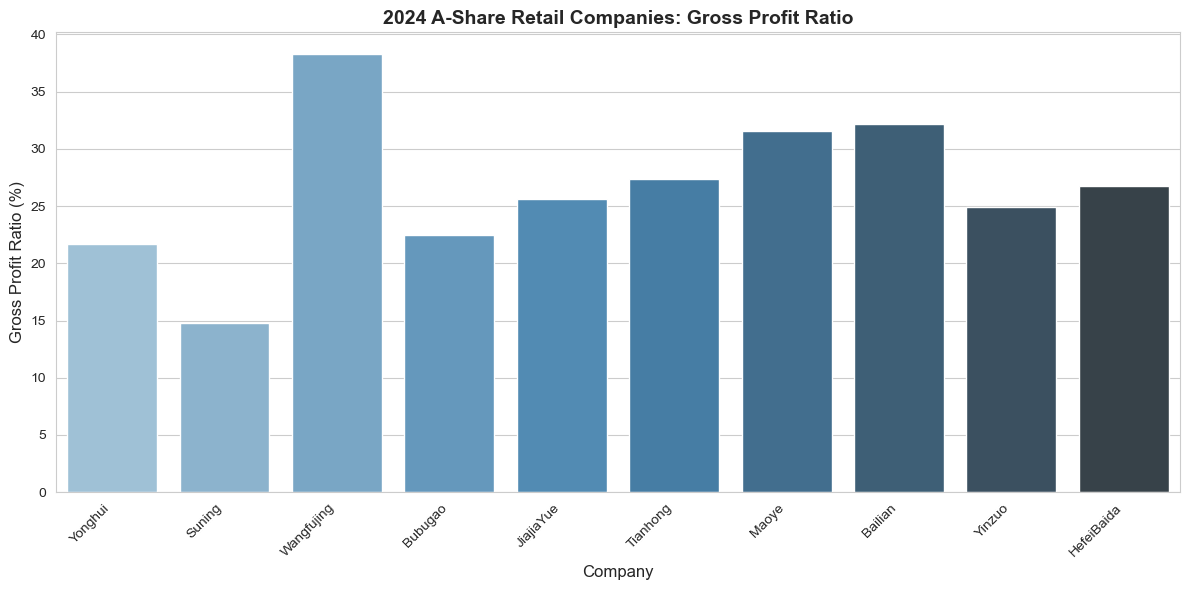

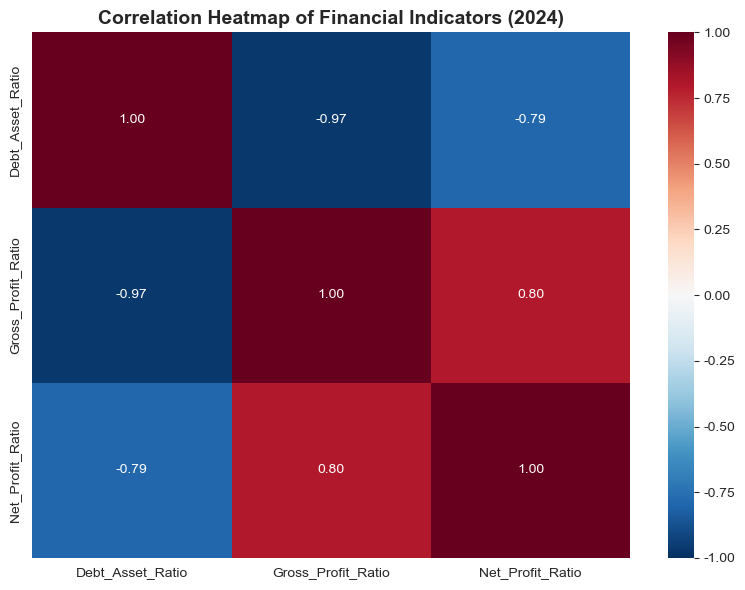

/var/folders/mt/8js2dy4d31vfxzqx6d8_ddhh0000gn/T/ipykernel_96750/4188715732.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Debt_Asset_Ratio', data=df, palette='Reds_d', ax=ax1)
/var/folders/mt/8js2dy4d31vfxzqx6d8_ddhh0000gn/T/ipykernel_96750/4188715732.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Net_Profit_Ratio', data=df, palette='Greens_d', ax=ax2)


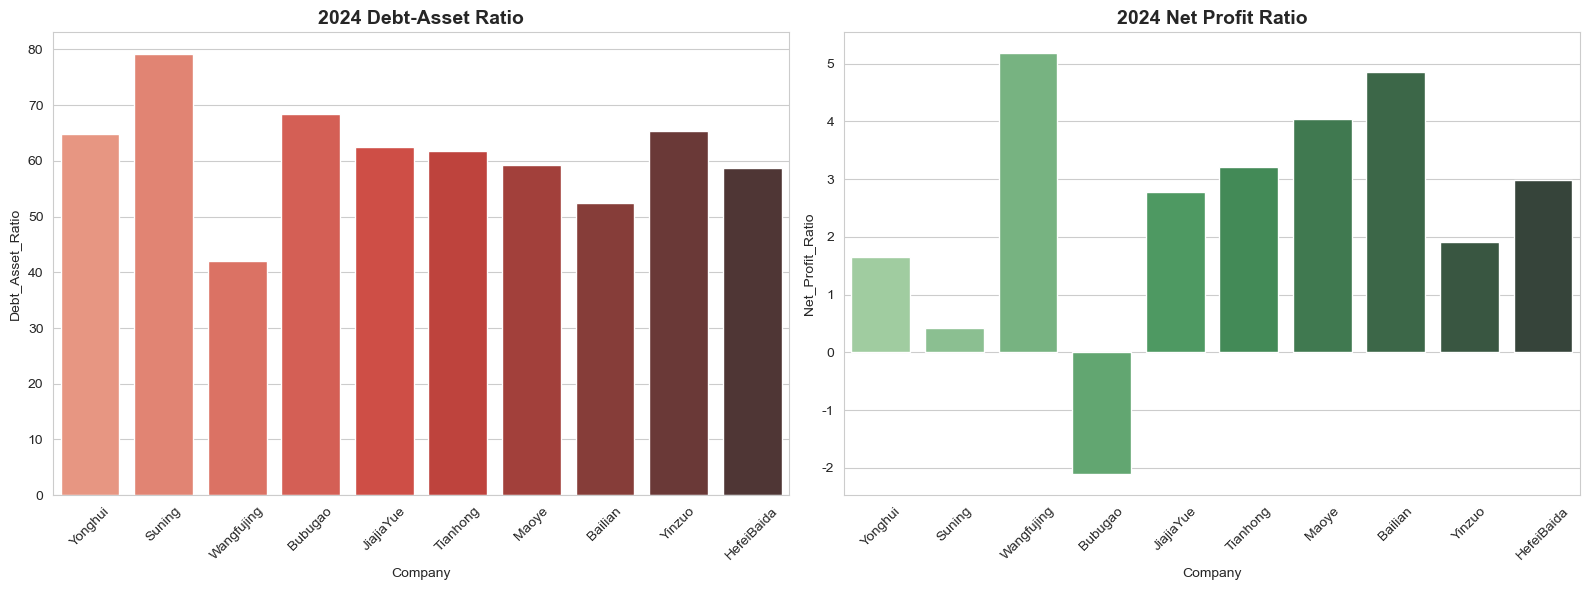


=== 📊 核心分析结果 ===
行业平均资产负债率：61.42%
行业平均毛利率：26.56%
行业平均净利率：2.5%

毛利率最高的公司：Wangfujing
资产负债率最低（偿债能力最强）的公司：Wangfujing
净利率最高的公司：Wangfujing

🎉 ✅ 分析流程全部完成！恭喜你搞定ACC102作业！


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mac系统字体设置，解决乱码和负号显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== 你的文件路径，完全正确，无需修改 ==========
file_path = "/Users/azamalfoy/Downloads/UNI/retail_finance_2024_raw.csv"

# 1. 读取数据，验证列名
df = pd.read_csv(file_path)
print("✅ 数据读取成功！列名验证：")
print(df.columns.tolist())
print("\n✅ 数据预览（前5行）：")
print(df.head())

# 2. 数据清洗
df = df.dropna()          # 删除空值
df = df.drop_duplicates() # 删除重复行

# 强制转换为数值型，避免格式错误
df['Debt_Asset_Ratio'] = pd.to_numeric(df['Debt_Asset_Ratio'], errors='coerce')
df['Gross_Profit_Ratio'] = pd.to_numeric(df['Gross_Profit_Ratio'], errors='coerce')
df['Net_Profit_Ratio'] = pd.to_numeric(df['Net_Profit_Ratio'], errors='coerce')

# 过滤异常值（符合财务逻辑，保证数据有效性）
df = df[(df['Debt_Asset_Ratio'] >= 0) & (df['Debt_Asset_Ratio'] <= 100)]
df = df[(df['Gross_Profit_Ratio'] >= 0) & (df['Gross_Profit_Ratio'] <= 100)]
df = df[(df['Net_Profit_Ratio'] >= -10) & (df['Net_Profit_Ratio'] <= 100)]

# 3. 保存清洗后的数据（同路径，方便管理）
cleaned_path = "/Users/azamalfoy/Downloads/UNI/retail_finance_2024_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"\n✅ 清洗完成！文件已保存至：{cleaned_path}")

# ========== 可视化图表 ==========
sns.set_style('whitegrid')

# 图1：各公司毛利率柱状图
plt.figure(figsize=(12, 6))
sns.barplot(x='Company', y='Gross_Profit_Ratio', data=df, palette='Blues_d')
plt.title('2024 A-Share Retail Companies: Gross Profit Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Company', fontsize=12)
plt.ylabel('Gross Profit Ratio (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/Users/azamalfoy/Downloads/UNI/Gross_Profit_Ratio_Bar.png", dpi=300)
plt.show()

# 图2：财务指标相关性热力图
corr = df[['Debt_Asset_Ratio', 'Gross_Profit_Ratio', 'Net_Profit_Ratio']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap of Financial Indicators (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/azamalfoy/Downloads/UNI/Financial_Indicators_Correlation.png", dpi=300)
plt.show()

# 图3：资产负债率 & 净利率 双图对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Company', y='Debt_Asset_Ratio', data=df, palette='Reds_d', ax=ax1)
sns.barplot(x='Company', y='Net_Profit_Ratio', data=df, palette='Greens_d', ax=ax2)

ax1.set_title('2024 Debt-Asset Ratio', fontsize=14, fontweight='bold')
ax2.set_title('2024 Net Profit Ratio', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/Users/azamalfoy/Downloads/UNI/Debt_Asset_Net_Profit_Subplot.png", dpi=300)
plt.show()

# ========== 输出核心分析结果（直接填作业报告用） ==========
print("\n=== 📊 核心分析结果 ===")
avg_debt = round(df['Debt_Asset_Ratio'].mean(), 2)
avg_gross = round(df['Gross_Profit_Ratio'].mean(), 2)
avg_net = round(df['Net_Profit_Ratio'].mean(), 2)

print(f"行业平均资产负债率：{avg_debt}%")
print(f"行业平均毛利率：{avg_gross}%")
print(f"行业平均净利率：{avg_net}%")

# 找出财务表现最优的公司
highest_gross = df.loc[df['Gross_Profit_Ratio'].idxmax(), 'Company']
lowest_debt = df.loc[df['Debt_Asset_Ratio'].idxmin(), 'Company']
highest_net = df.loc[df['Net_Profit_Ratio'].idxmax(), 'Company']

print(f"\n毛利率最高的公司：{highest_gross}")
print(f"资产负债率最低（偿债能力最强）的公司：{lowest_debt}")
print(f"净利率最高的公司：{highest_net}")

print("\n🎉 ✅ 分析流程全部完成！恭喜你搞定ACC102作业！")